In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

if "../" not in sys.path:
    sys.path.append("../")

In [3]:
print("[sys.path]:", sys.path)

[sys.path]: ['/Users/nadir/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages', '/Users/nadir/Documents/research-project/code/experimentations/gymnasium/src', '../']


In [4]:
import os
import time
import tqdm

import src.helpers as helpers
import src.environments.cristal as cristal

import src.controllers.dqn as dqn
import src.controllers.ppo as ppo
import src.controllers.clothoids as clothoids
import src.controllers.purepursuit as purepursuit

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

objc[36040]: Class SDLApplication is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x10d8c52c8) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1431f0890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[36040]: Class SDLAppDelegate is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x10d8c5318) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1431f08e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[36040]: Class SDLTransl

In [ ]:
# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/13-59-36/"

# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/21-12-59" # learned wit a static obstacle
# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/20-54-02" # learned with random obstacles

In [9]:
output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/14-50-04"

configuration = helpers.load_configuration(
    output_directory=output_directory,
    expected_script="train",
)

controller, environment = helpers.instantiate_configuration(
    configuration=configuration,
    output_directory=output_directory,
    load_best_model=True
)

environment.unwrapped.render_mode = "rgb_array"

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


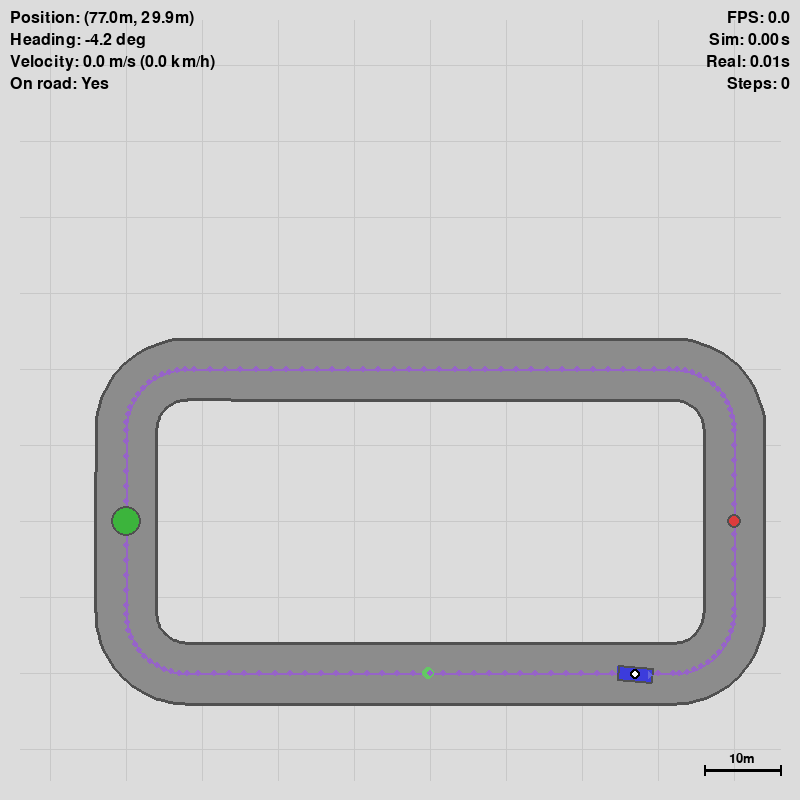

In [26]:
environment.reset()

helpers.preview(environment)

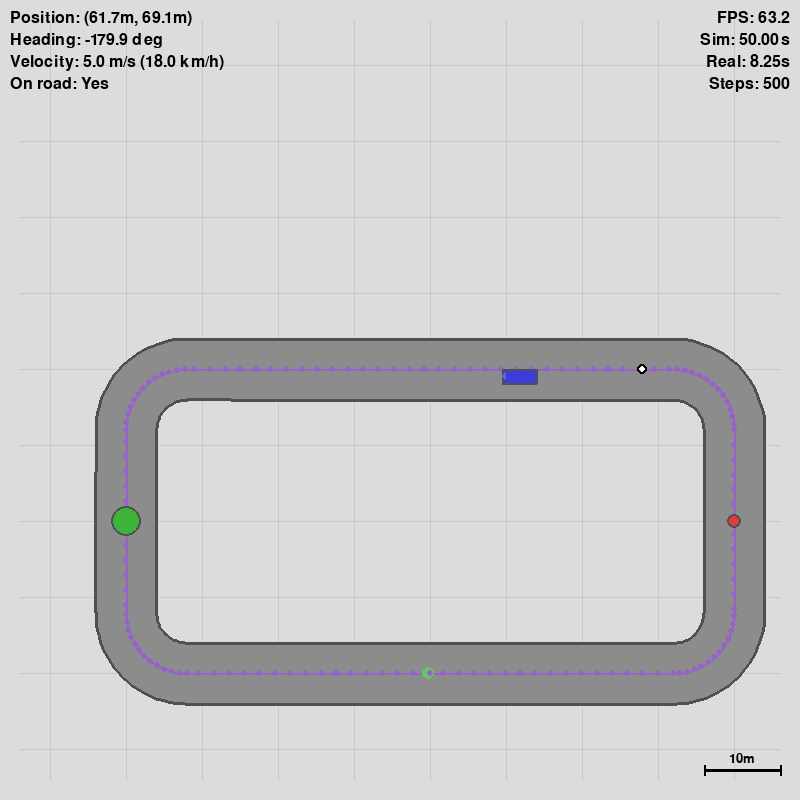

In [29]:
observation, info = environment.reset()

for i in range(500):
    print(observation)
    action, _states = controller.get_action(observation=observation)
    
    observation, reward, terminated, truncated, info = environment.step(action)
    
    environment.unwrapped.overlay_manager.clear()
    controller.draw_debug(environment=environment, observation=observation, path=environment.unwrapped.path)
    
    helpers.preview(environment)

    if terminated or truncated:
        break

environment.close()